# Customer Behavior Analysis

## Objective

The goal of this phase is to analyze customer service usage, contract types, billing methods, and financial characteristics to identify the strongest drivers of customer churn.

In [1]:
%pip install seaborn

In [2]:
# ============================
# Import Libraries
# ============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# ============================
# Load Clean Dataset
# ============================

df = pd.read_csv(
    "/drive/customer-churn-analytics-project/data/customer_churn_cleaned.csv"
)

df.head()

,City,Zip Code,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,Los Angeles,90003,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,Los Angeles,90005,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,Los Angeles,90006,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,Los Angeles,90010,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,Los Angeles,90015,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


# Contract Type Analysis

Customer contract duration is often one of the strongest predictors of churn behavior.

This section evaluates how churn rates vary across contract types.

In [3]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn Label,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


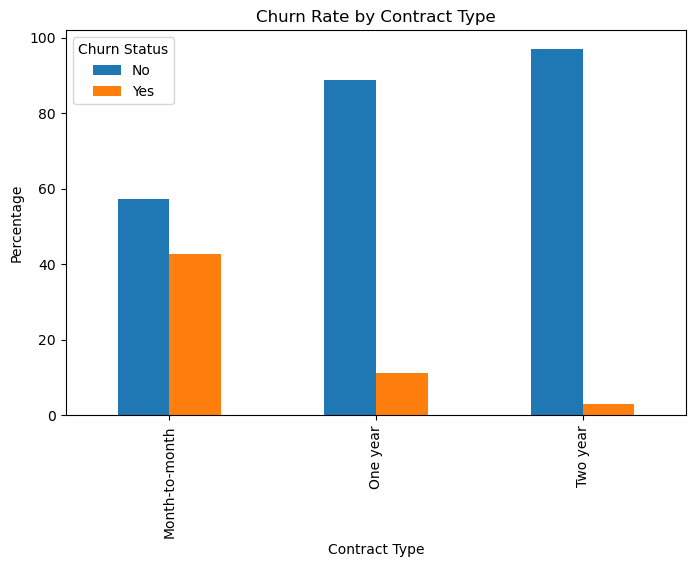

In [4]:
contract_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Contract Type")
plt.ylabel("Percentage")
plt.xlabel("Contract Type")

plt.legend(title="Churn Status")

plt.show()

### Insight

Contract type is the strongest churn indicator observed so far.

Customers on month-to-month contracts exhibit a churn rate of 42.71%, compared to only 2.85% among customers with two-year contracts.

This suggests that long-term contracts significantly improve customer retention and reduce churn risk.

# Internet Service Analysis

Internet service offerings may influence customer satisfaction and retention outcomes.

In [5]:
internet_churn = pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
) * 100

internet_churn.round(2)

Churn Label,No,Yes
Internet Service,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


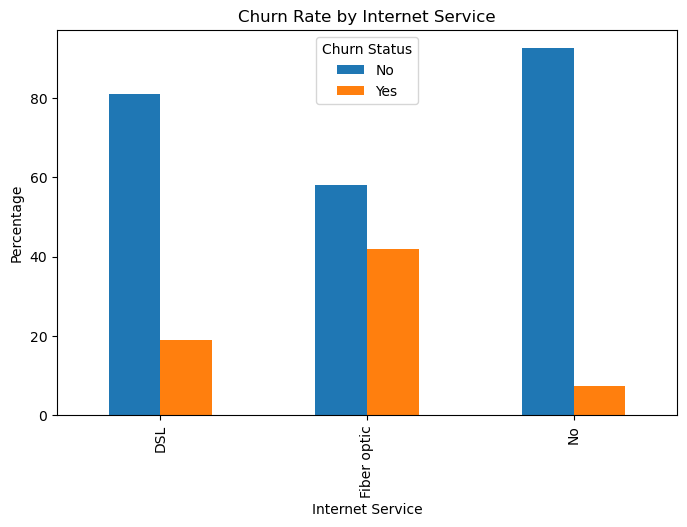

In [6]:
internet_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Internet Service")
plt.ylabel("Percentage")
plt.xlabel("Internet Service")

plt.legend(title="Churn Status")

plt.show()

### Insight

Fiber optic customers exhibit the highest churn rate (41.89%), more than double the churn rate of DSL customers.

This finding may indicate pricing, service quality, or customer expectation challenges within the fiber optic segment.

In [7]:
tech_churn = pd.crosstab(
    df["Tech Support"],
    df["Churn Label"],
    normalize="index"
) * 100

tech_churn.round(2)

Churn Label,No,Yes
Tech Support,,
No,58.35,41.65
No internet service,92.57,7.43
Yes,84.80,15.20


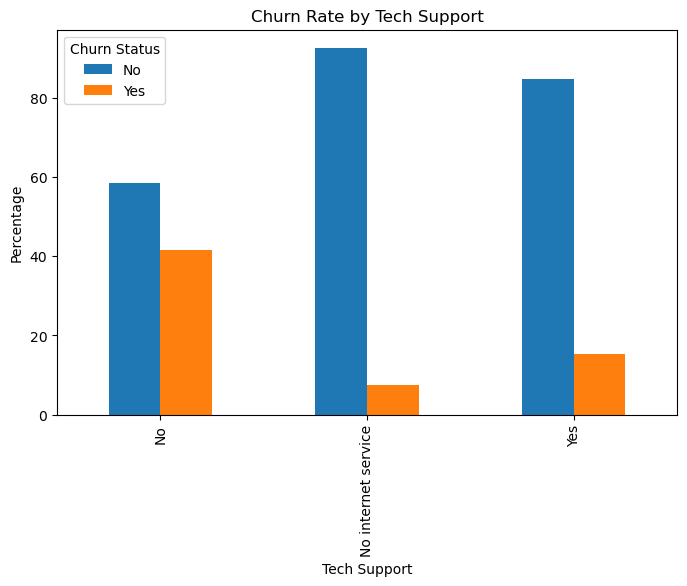

In [8]:
tech_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Tech Support")
plt.ylabel("Percentage")
plt.xlabel("Tech Support")

plt.legend(title="Churn Status")

plt.show()

### Insight

Customers without technical support are significantly more likely to churn.

Providing technical support appears to reduce churn from 41.65% to 15.20%, highlighting its importance as a retention service.

In [9]:
security_churn = pd.crosstab(
    df["Online Security"],
    df["Churn Label"],
    normalize="index"
) * 100

security_churn.round(2)

Churn Label,No,Yes
Online Security,,
No,58.22,41.78
No internet service,92.57,7.43
Yes,85.36,14.64


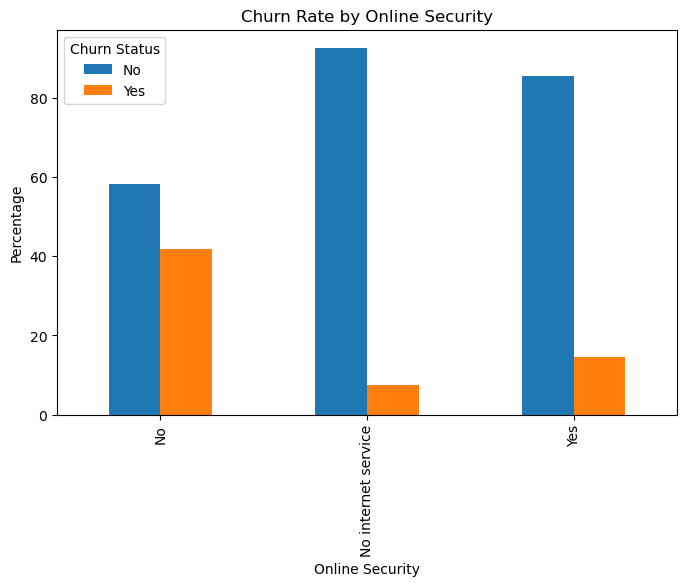

In [10]:
security_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Online Security")
plt.ylabel("Percentage")
plt.xlabel("Online Security")

plt.legend(title="Churn Status")

plt.show()

### Insight

Online security services are strongly associated with customer retention.

Customers who subscribe to online security exhibit substantially lower churn rates compared to customers without the service.

In [11]:
payment_churn = pd.crosstab(
    df["Payment Method"],
    df["Churn Label"],
    normalize="index"
) * 100

payment_churn.round(2)

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


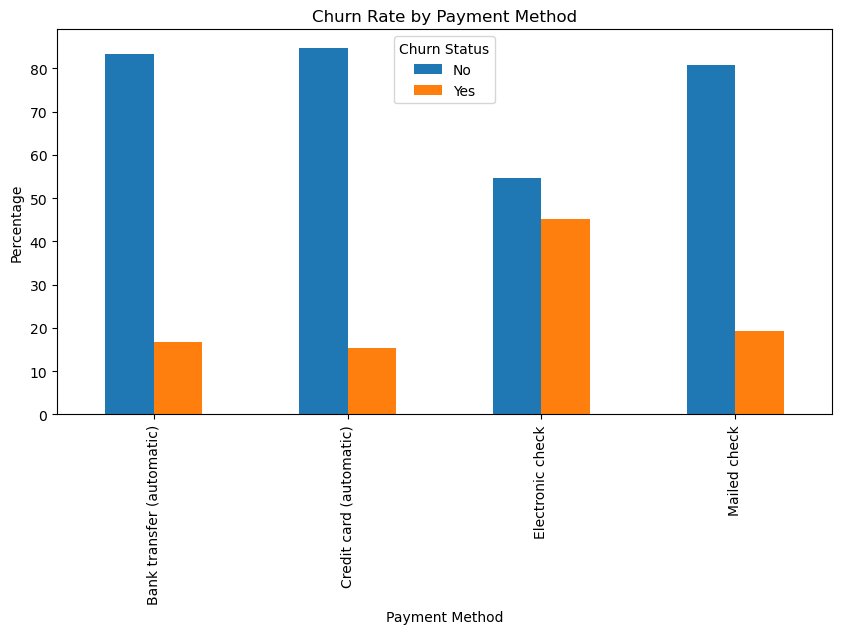

In [12]:
payment_churn.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Churn Rate by Payment Method")
plt.ylabel("Percentage")
plt.xlabel("Payment Method")

plt.legend(title="Churn Status")

plt.show()

### Insight

Customers using electronic checks experience the highest churn rate in the dataset (45.29%).

Automatic payment methods are associated with substantially lower churn rates, suggesting that payment convenience contributes to customer retention.

# Monthly Charges Analysis

Monthly subscription fees may influence customer satisfaction and retention.

This section examines whether customers who pay higher monthly charges are more likely to churn.

In [13]:
monthly_charges = df.groupby(
    "Churn Label"
)["Monthly Charges"].mean()

monthly_charges

Churn Label
No     61.307408
Yes    74.441332
Name: Monthly Charges, dtype: float64

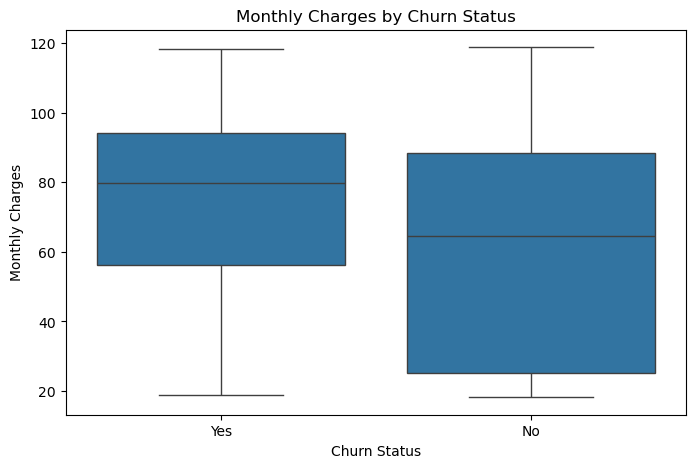

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.show()

### Insight

Customers who churned paid an average monthly charge of $74.44, compared to $61.31 for retained customers.

This finding suggests that higher monthly costs may contribute to customer attrition, potentially due to pricing sensitivity or perceived value concerns.

# Customer Tenure Analysis

Customer tenure represents the length of the customer relationship with the company.

This section investigates whether customer longevity is associated with churn behavior.

In [15]:
tenure_analysis = df.groupby(
    "Churn Label"
)["Tenure Months"].mean()

tenure_analysis

Churn Label
No     37.650010
Yes    17.979133
Name: Tenure Months, dtype: float64

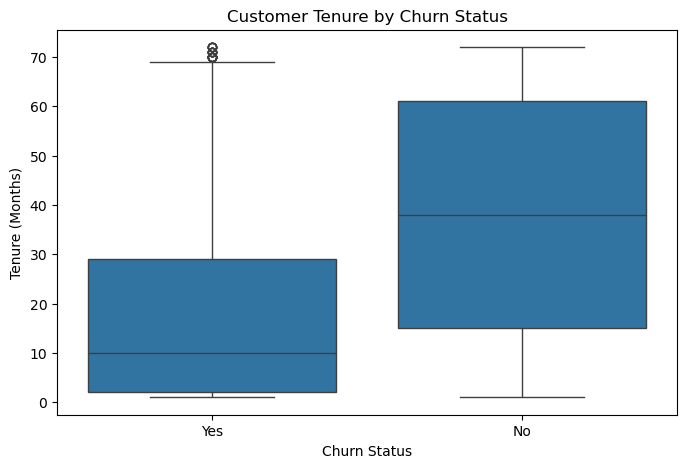

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Tenure Months"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")

plt.show()

### Insight

Churned customers had an average tenure of 17.98 months, compared to 37.65 months among retained customers.

This indicates that customer churn is concentrated among newer customers, while long-term customers are substantially more likely to remain with the company.

# Customer Behavior Findings

This analysis identified several strong drivers of customer churn.

Key factors associated with higher churn include:

- Month-to-month contracts
- Fiber optic internet service
- Lack of technical support
- Lack of online security services
- Electronic check payment methods
- Higher monthly charges
- Short customer tenure

Notably, customers with long-term contracts, lower monthly charges, and longer tenure demonstrate significantly higher retention rates.

These findings suggest that contract commitment, service engagement, customer support, and pricing dynamics play critical roles in customer retention.